True Time: 1234
Estimated Time: 1234
Reconstruction Error: 0


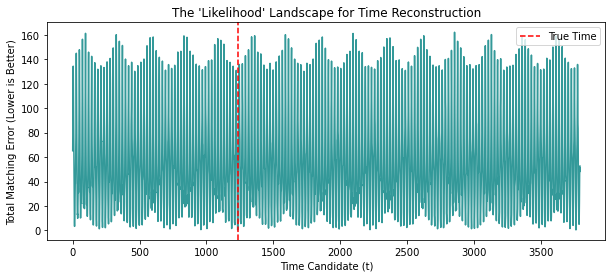

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_time_robust(measured_phases, frequencies, max_range):
    """
    Finds the time 't' that best fits all measured phases simultaneously.
    This is much more stable than the standard CRT formula.
    """
    # Create a range of possible 'candidate' times
    t_candidates = np.arange(0, max_range, 1)
    
    # Calculate the 'residual' error for every possible time
    # We want to find t where (t % freq) is closest to measured_phase
    total_error = np.zeros_like(t_candidates, dtype=float)
    
    for phi, freq in zip(measured_phases, frequencies):
        # Expected remainder for this candidate time
        expected = t_candidates % freq
        # Circular distance (since phase 0.1 is close to 0.9 on a clock)
        diff = np.abs(expected - phi)
        # Handle the wrap-around (e.g., if freq=10, 0 and 9 are 1 unit apart)
        diff = np.minimum(diff, freq - diff)
        total_error += diff**2
        
    # The best estimate is the time that minimizes the total error
    best_t = t_candidates[np.argmin(total_error)]
    return best_t, total_error

# 1. Define your Frequencies (The "m" values from CRT)
# Let's use your Prime-Binary set:
periods = [3, 5, 11, 23] 
max_period = np.lcm.reduce(periods)  # BUG FIX #2: was np.prod — use lcm for dynamic range

# 2. Simulate a "True Time" we want to measure
t_true = 1234

# 3. Simulate Quantum Measurement (with 5% noise)
noise_scale = 0.2
# BUG FIX #1: was "frequencies" (undefined) — should be "periods"
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

# --- Visualization of the Search Space ---
plt.figure(figsize=(10, 4))
plt.plot(error_curve, color='teal', alpha=0.8)
plt.axvline(t_true, color='red', linestyle='--', label='True Time')
plt.title("The 'Likelihood' Landscape for Time Reconstruction")
plt.xlabel("Time Candidate (t)")
plt.ylabel("Total Matching Error (Lower is Better)")
plt.legend()
plt.show()

In [13]:
# 1. Define your Frequencies (The "m" values from CRT)
# Let's use your Prime-Binary set:
periods = [3, 5, 7, 11, 17] 
max_period = np.lcm.reduce(periods) # This is our Dynamic Range (19635)
print(max_period)

# 2. Simulate a "True Time" we want to measure
t_true = 10415

# 3. Simulate Quantum Measurement 
noise_scale = 0.1
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

19635
True Time: 10415
Estimated Time: 10415
Reconstruction Error: 0


In [17]:
# 1. Define your Frequencies (The "m" values from CRT)
# Seth's Hitchhiker's set of periods:
periods = [42, 43, 47] 
max_period = np.lcm.reduce(periods)

# 2. Simulate a "True Time" we want to measure
t_true = 23897

# 3. Simulate Quantum Measurement 
noise_scale = 5
# BUG FIX #1: was "frequencies" (undefined) — should be "periods"
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

True Time: 23897
Estimated Time: 68746
Reconstruction Error: 44849


In [3]:
print(np.lcm.reduce(periods))

84882


In [7]:
import numpy as np

def reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma=1.0):
    """
    Implementation of the Robust Phase Unwrapping algorithm
    from Xia & Wang (Equations 6-11).
    """
    L = len(lambdas)
    # Step 1: Calculate coprime factors Gamma_i (Eq 4)
    Gammas = [int(round(Gamma * l)) for l in lambdas]
    
    # Step 2: Calculate gamma_i values (Eq 5)
    # gamma_1 = product of all Gamma_j for j != 1
    gamma_1 = np.prod(Gammas[1:])
    
    # Precompute gamma_i for each i (product of all Gamma_j for j != i)
    # Needed to constrain ni_hat search range per Eq 6
    gamma_all = []
    for idx in range(L):
        g = 1
        for j in range(L):
            if j != idx:
                g *= Gammas[j]
        gamma_all.append(g)
    
    # Step 3: Find S_i sets (Eq 6 & 7)
    # For each pair (channel 1, channel i), find n1 candidates that minimize
    # |n_bar_i * M_i + r_tilde_i - n_bar_1 * M_1 - r_tilde_1|
    S_i_1 = [] 
    
    for i in range(1, L): 
        best_diff = float('inf')
        S_i_current = []
        gamma_i = gamma_all[i]  # valid range for n_bar_i
        
        # Search range for n1_hat: [0, gamma_1 - 1] per Eq 6
        for n1_hat in range(gamma_1):
            val_1 = n1_hat * Gammas[0] + (k_tilde[0] * Gammas[0]) / M
            
            # BUG FIX #3: Compute ni_hat by rounding, then CLAMP to valid range [0, gamma_i - 1]
            # Per Eq 6, n_bar_i must be in [0, gamma_i - 1].
            # Without this, out-of-range ni_hat values produce artificially small residuals
            # that can pollute the candidate sets.
            ni_hat_raw = (val_1 - (k_tilde[i] * Gammas[i]) / M) / Gammas[i]
            ni_hat = int(round(ni_hat_raw))
            ni_hat = max(0, min(gamma_i - 1, ni_hat))  # Clamp to valid range
            
            # Calculate the residual for this candidate pair (Eq 6)
            current_diff = abs(ni_hat * Gammas[i] + (k_tilde[i] * Gammas[i]) / M - 
                               n1_hat * Gammas[0] - (k_tilde[0] * Gammas[0]) / M)
            
            if current_diff < best_diff - 1e-9: # Found a new better minimum
                best_diff = current_diff
                S_i_current = [n1_hat]
            elif abs(current_diff - best_diff) < 1e-9: # Tied with current minimum
                S_i_current.append(n1_hat)
        
        S_i_1.append(set(S_i_current))

    # Step 4: Intersection of all candidate sets (Eq 8)
    S = S_i_1[0].intersection(*S_i_1[1:])
    
    if len(S) != 1:
        return None, f"Failure: Found {len(S)} possible solutions. Theorem 1 bounds likely violated."
    
    n1 = list(S)[0]
    
    # Step 5: Solve for all folding integers ni based on the unique n1
    n_all = [n1]
    for i in range(1, L):
        val_1 = n1 * Gammas[0] + (k_tilde[0] * Gammas[0]) / M
        ni = int(round((val_1 - (k_tilde[i] * Gammas[i]) / M) / Gammas[i]))
        n_all.append(ni)
        
    # Step 6: Final estimate of x using the averaging formula (Eq 11)
    estimate_x = (1 / (sigma * L)) * sum((n_all[i] + k_tilde[i] / M) * lambdas[i] for i in range(L))
    
    return estimate_x, n_all

# --- EXAMPLE CASE (Section IV Parameters) ---
sigma = 1.0
Gamma = 10
lambdas = [0.4, 0.5, 0.7] # Corresponding to Gammas = [4, 5, 7]
tau = 2 # Max remainder error level

# M must satisfy Theorem 1 condition: M > 4 * tau * max(Gamma_i)
# Effective error in remainder space = tau * Gamma_i, worst case = tau * max(Gamma_i) = 2*7 = 14
# So need M > 4 * 14 = 56. Using M = 60 is valid (barely).
M = 60 

# Dynamic range: t < (1 / (sigma * Gamma)) * prod(Gammas) = (1/10) * 140 = 14.0
t_true = 9.85

# Simulate the remainders k_i that would be measured
k_tilde = []
for l in lambdas:
    f_i = (sigma * t_true) / l
    k_true = (f_i - np.floor(f_i)) * M
    # Add random error up to tau
    error = np.random.uniform(-tau, tau)
    k_measured = int(round(k_true + error)) % M
    k_tilde.append(k_measured)

# Run Reconstruction
t_est, folding_ints = reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma)

print(f"True Time (t): {t_true}")
print(f"Measured Remainders (k_tilde): {k_tilde}")
print(f"Estimated t: {t_est}")
print(f"Folding Integers (n_i): {folding_ints}")
print(f"Error: {abs(t_true - t_est):.5f}")

True Time (t): 9.85
Measured Remainders (k_tilde): [39, 42, 3]
Estimated t: 9.848333333333333
Folding Integers (n_i): [24, 19, 14]
Error: 0.00167


In [24]:
# --- EXAMPLE CASE 2: More wavelengths ---
sigma = 1.0
Gamma = 10
lambdas = [0.4, 0.5, 0.7, 0.9] # Corresponding to Gammas = [4, 5, 7, 9]
tau = 10 # Max remainder error level

# BUG FIX #4: tau=4, M=60 violated Theorem 1.
# Effective error bound = tau * max(Gamma_i) = tau * 9.
# Theorem 1 requires M > 4 * (tau * max(Gamma_i)):
#   Old: M=60 > 4 * 4 * 9 = 144  => VIOLATED
#   Fix: reduce tau to 2 => M=60 > 4 * 2 * 9 = 72 => still violated!
#   Better fix: increase M. Need M > 4 * tau * 9 = 72 for tau=2. Use M=80.
M = 80 

# Dynamic range: t < (1 / (sigma * Gamma)) * prod(Gammas) = (1/10) * (4*5*7*9) = 126.0
t_true = 50

# Simulate the remainders k_i that would be measured
k_tilde = []
for l in lambdas:
    f_i = (sigma * t_true) / l
    k_true = (f_i - np.floor(f_i)) * M
    # Add random error up to tau
    error = np.random.uniform(-tau, tau)
    k_measured = int(round(k_true + error)) % M
    k_tilde.append(k_measured)

# Run Reconstruction
t_est, folding_ints = reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma)

print(f"True Time (t): {t_true}")
print(f"Measured Remainders (k_tilde): {k_tilde}")
print(f"Estimated t: {t_est}")
print(f"Folding Integers (n_i): {folding_ints}")
print(f"Error: {abs(t_true - t_est):.5f}")

True Time (t): 50
Measured Remainders (k_tilde): [75, 76, 35, 45]
Estimated t: 49.990625
Folding Integers (n_i): [124, 99, 71, 55]
Error: 0.00937


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- Scientific plotting settings ---
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 16
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['axes.linewidth'] = 1.2

# --- Simulation parameters ---
N_trials  = 2000
t_true    = 7791
sigma     = 1.0
Gamma     = 10
lambdas   = [0.4, 0.5, 0.7, 0.9]   # Gammas = [4, 5, 7, 9]
max_Gamma = max(int(round(Gamma * l)) for l in lambdas)  # = 9

tau_values = [5, 10, 15, 20]

# M is held constant — Theorem 1 requires M > 4 * tau * max_Gamma = 36*tau
# With M=400: threshold is tau < 400/36 ≈ 11.1  →  tau=5,10 valid; tau=15,20 violated
M = 400

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, tau in enumerate(tau_values):
    threshold = 4 * tau * max_Gamma
    valid = M > threshold

    t_est_list = []
    n_failed   = 0

    for _ in range(N_trials):
        k_tilde = []
        for l in lambdas:
            f_i    = (sigma * t_true) / l
            k_true = (f_i - np.floor(f_i)) * M
            error  = np.random.uniform(-tau, tau)
            k_meas = int(round(k_true + error)) % M
            k_tilde.append(k_meas)

        t_est, _ = reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma)

        if t_est is not None:
            t_est_list.append(t_est)
        else:
            n_failed += 1

    ax = axes[idx]
    color = 'steelblue' if valid else 'tomato'

    if t_est_list:
        errors = np.array(t_est_list) - t_true
        rmse   = np.sqrt(np.mean(errors**2))
        bias   = np.mean(errors)
        ax.hist(errors, bins=60, color=color, edgecolor='white',
                linewidth=0.4, alpha=0.85, density=True)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.8, label='Zero error')
        ax.legend(loc='upper left')
        stats_text = (f'RMSE  = {rmse:.4f}\n'
                      f'Bias    = {bias:.4f}\n'
                      f'Failures = {n_failed}/{N_trials}')
    else:
        stats_text = f'Failures = {n_failed}/{N_trials}\n(all trials failed)'

    status = '✓ Valid' if valid else f'✗ Violated  (need M > {threshold})'
    ax.set_title(f'$\\tau = {tau}$    Theorem 1: {status}', pad=10)
    ax.set_xlabel(r'Estimation Error $\,\hat{t} - t_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

fig.suptitle(
    f'Robust CRT: Effect of Noise Level $\\tau$ with Fixed $M = {M}$\n'
    f'$t_{{\\mathrm{{true}}}} = {t_true}$,  Theorem 1 bound: $M > 4\\tau\\,\\Gamma_{{\\max}} = 36\\tau$',
    fontsize=17, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


RuntimeError: latex was not able to process the following string:
b'$\\\\tau = 5$    Theorem 1: \\u2713 Valid'

Here is the full report generated by latex:
This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(/Users/a1/.matplotlib/tex.cache/c0fc30cafa94a199e2ec2c2f2e653e60.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2023/texmf-dist/

RuntimeError: latex was not able to process the following string:
b'$\\\\tau = 5$    Theorem 1: \\u2713 Valid'

Here is the full report generated by latex:
This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(/Users/a1/.matplotlib/tex.cache/c0fc30cafa94a199e2ec2c2f2e653e60.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2023/texmf-dist/

<Figure size 1950x1500 with 4 Axes>

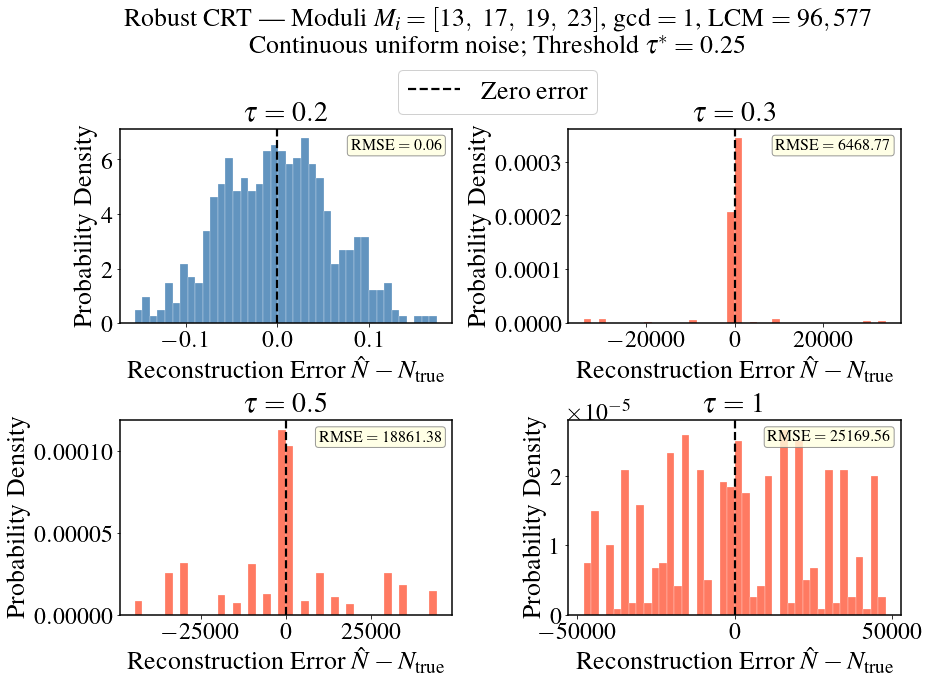

In [3]:
from math import gcd, prod, lcm
from functools import reduce
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 26,
    'axes.titlesize'      : 28,
    'axes.labelsize'      : 26,
    'xtick.labelsize'     : 24,
    'ytick.labelsize'     : 24,
    'legend.fontsize'     : 22,
    'axes.linewidth'      : 1.5,
})

def robust_crt_int(r_tilde, moduli):
    """Accepts float r_tilde and non-integer inputs — returns float estimate."""
    L = len(moduli)
    M_g = reduce(gcd, moduli)
    Gammas = [m // M_g for m in moduli]
    gamma = [prod(Gammas[j] for j in range(L) if j != i) for i in range(L)]
    S_sets = []
    for i in range(1, L):
        best_diff, candidates = float('inf'), []
        for n1_hat in range(gamma[0]):
            ni_hat = round((n1_hat * moduli[0] + r_tilde[0] - r_tilde[i]) / moduli[i])
            ni_hat = max(0, min(gamma[i] - 1, ni_hat))
            diff = abs(ni_hat * moduli[i] + r_tilde[i]
                       - n1_hat * moduli[0] - r_tilde[0])
            if diff < best_diff - 1e-9:
                best_diff, candidates = diff, [n1_hat]
            elif abs(diff - best_diff) < 1e-9:
                candidates.append(n1_hat)
        S_sets.append(set(candidates))
    S = S_sets[0].intersection(*S_sets[1:])
    if len(S) != 1:
        return None
    n1 = list(S)[0]
    n_all = [n1] + [round((n1 * moduli[0] + r_tilde[0] - r_tilde[i]) / moduli[i])
                    for i in range(1, L)]
    return sum(n_all[i] * moduli[i] + r_tilde[i] for i in range(L)) / L

moduli    = [13, 17, 19, 23]
M_gcd     = reduce(gcd, moduli)
M_lcm     = reduce(lcm, moduli)
threshold = M_gcd / 4

N_trials   = 500
tau_values = [0.2, 0.3, 0.5, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.35, top=0.80)
rng = np.random.default_rng(42)

legend_handle = None

for idx, tau in enumerate(tau_values):
    errors   = []
    n_failed = 0

    for _ in range(N_trials):
        N_true  = rng.uniform(0, M_lcm)
        rems    = [N_true % m for m in moduli]
        noise   = rng.uniform(-tau, tau, size=len(moduli)).tolist()
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = robust_crt_int(noisy_r, moduli)
        if result is not None:
            err = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
            errors.append(err)
        else:
            n_failed += 1

    ax    = axes.flatten()[idx]
    valid = (tau < threshold)
    color = 'steelblue' if valid else 'tomato'

    if errors:
        errors_arr = np.array(errors, dtype=float)
        rmse       = np.sqrt(np.mean(errors_arr ** 2))
        ax.hist(errors_arr, bins=40, color=color, edgecolor='white',
                linewidth=0.3, alpha=0.85, density=True)
        line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                          label='Zero error')
        if legend_handle is None:
            legend_handle = line
        stats_text = rf'RMSE $= {rmse:.2f}$'
        ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
                ha='right', va='top', fontsize=16,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$\tau = {tau}$', pad=8)
    ax.set_xlabel(r'Reconstruction Error $\hat{N} - N_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')

moduli_str = '[' + ',\\ '.join(str(m) for m in moduli) + ']'
fig.suptitle(
    rf'Robust CRT --- Moduli $M_i = {moduli_str}$,  gcd~$= {M_gcd}$,  LCM~$= {M_lcm:,}$'
    + '\n' +
    rf'Continuous uniform noise; Threshold~$\tau^* = {threshold:.2f}$',
    fontsize=26, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.9), ncol=1, framealpha=0.9, fontsize=26)

fig.savefig('CRT_robust_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_robust_simulation.pdf', bbox_inches='tight')
plt.show()


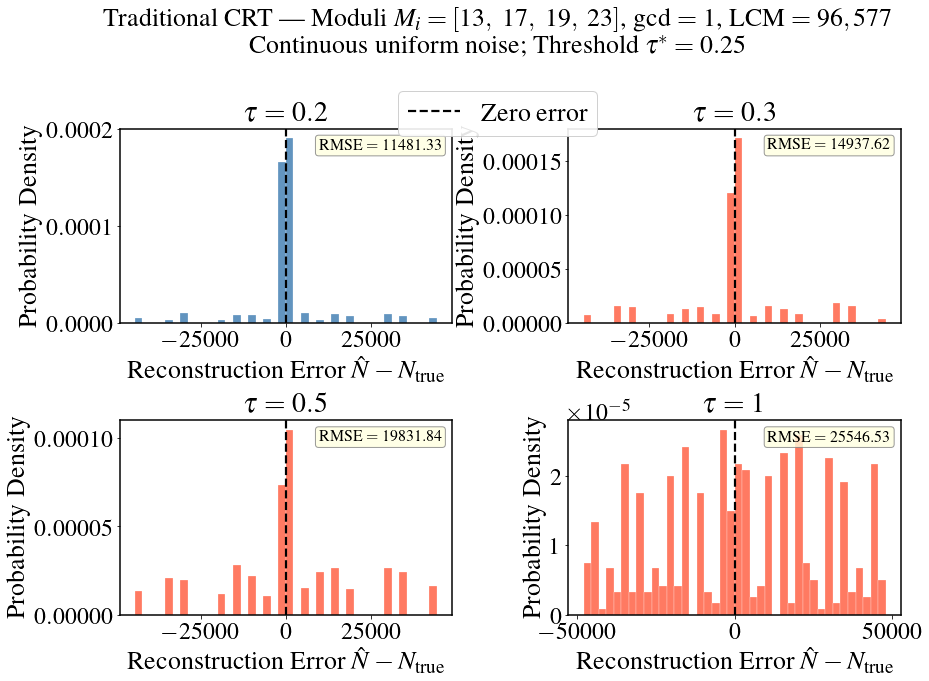

In [4]:
def traditional_crt(r_tilde, moduli):
    """Standard CRT: rounds noisy remainders to integers, then applies the CRT formula."""
    M = reduce(lcm, moduli)
    result = 0
    for r, m in zip(r_tilde, moduli):
        r_int = round(r) % m
        Mi    = M // m
        result += r_int * Mi * pow(Mi, -1, m)
    return result % M

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.35, top=0.80)
rng = np.random.default_rng(42)

legend_handle = None

for idx, tau in enumerate(tau_values):
    errors = []

    for _ in range(N_trials):
        N_true  = rng.uniform(0, M_lcm)
        rems    = [N_true % m for m in moduli]
        noise   = rng.uniform(-tau, tau, size=len(moduli)).tolist()
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = traditional_crt(noisy_r, moduli)
        err     = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
        errors.append(err)

    ax    = axes.flatten()[idx]
    valid = (tau < threshold)
    color = 'steelblue' if valid else 'tomato'

    errors_arr = np.array(errors, dtype=float)
    rmse       = np.sqrt(np.mean(errors_arr ** 2))
    ax.hist(errors_arr, bins=40, color=color, edgecolor='white',
            linewidth=0.3, alpha=0.85, density=True)
    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line
    ax.text(0.97, 0.95, rf'RMSE $= {rmse:.2f}$', transform=ax.transAxes,
            ha='right', va='top', fontsize=16,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$\tau = {tau}$', pad=8)
    ax.set_xlabel(r'Reconstruction Error $\hat{N} - N_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')

fig.suptitle(
    rf'Traditional CRT --- Moduli $M_i = {moduli_str}$,  gcd~$= {M_gcd}$,  LCM~$= {M_lcm:,}$'
    + '\n' +
    rf'Continuous uniform noise; Threshold~$\tau^* = {threshold:.2f}$',
    fontsize=26, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.87), ncol=1, framealpha=0.9, fontsize=26)

fig.savefig('CRT_traditional_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_traditional_simulation.pdf', bbox_inches='tight')
plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from math import prod
from functools import reduce
import matplotlib as mpl

# ============================================================
# Publication-quality: full LaTeX rendering + Times New Roman
# (text and math).  Requires LaTeX with mathptmx + amssymb.
# ============================================================
mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 18,
    'axes.titlesize'      : 19,
    'axes.labelsize'      : 18,
    'xtick.labelsize'     : 16,
    'ytick.labelsize'     : 16,
    'legend.fontsize'     : 16,
    'axes.linewidth'      : 1.4,
    'figure.dpi'          : 150,
})

# ============================================================
# What is M?
# ------------------------------------------------------------
# M is the number of discrete phase-quantisation bins per cycle.
# Channel i measures the fractional frequency ratio
#   phi_i = frac(sigma * t / lambda_i)  in [0, 1)
# and quantises it to an integer measurement:
#   k_i = round(phi_i * M)  in {0, 1, ..., M-1}
#
# Larger M => finer resolution => wider noise tolerance, because
# Theorem 1 (Xia & Wang 2013) requires  M > 4*tau*Gamma_max,
# giving  tau* = M / (4 * Gamma_max).
# ============================================================

primes   = [13, 17, 19, 23, 29]
Gamma    = 29
lambdas  = [p / Gamma for p in primes]   # lambda_i = p_i / 29
sigma    = 1.0
t_true   = 7791.0
M        = 500   # phase bins: k_i in {0,...,499}; tau* = 500/116 ≈ 4.31
N_trials = 1000

Gammas    = [int(round(Gamma * l)) for l in lambdas]   # recovers primes exactly
max_Gamma = max(Gammas)           # = 29
threshold = M / (4 * max_Gamma)   # ≈ 4.31

assert Gammas == primes
assert t_true < prod(Gammas) / (sigma * Gamma), "t_true exceeds dynamic range"

print(f"M = {M}  (phase bins: k_i in {{0,...,{M-1}}})")
print(f"Primes / Gammas    : {Gammas}")
print(f"Dynamic range      : {prod(Gammas)/(sigma*Gamma):.1f}")
print(f"Threshold: tau < M / (4*Gamma_max) = {M} / {4*max_Gamma} = {threshold:.2f}")

# ============================================================
# Vectorised Xia & Wang reconstruction.
# The inner search is over n1 in [0, gamma_1) = [0, 215441),
# done in a single numpy pass instead of a Python for-loop.
# ============================================================
_n1_cache = {}

def _fast_crt(k_tilde, lambdas, M, Gamma, sigma):
    L      = len(lambdas)
    Gs     = [int(round(Gamma * l)) for l in lambdas]
    g1     = prod(Gs[1:])
    g_all  = [prod(Gs[j] for j in range(L) if j != i) for i in range(L)]
    if g1 not in _n1_cache:
        _n1_cache[g1] = np.arange(g1, dtype=np.int64)
    n1    = _n1_cache[g1]
    base1 = n1 * Gs[0] + k_tilde[0] * Gs[0] / M
    S_sets = []
    for i in range(1, L):
        bi     = k_tilde[i] * Gs[i] / M
        ni_raw = (base1 - bi) / Gs[i]
        ni_hat = np.clip(np.round(ni_raw).astype(np.int64), 0, g_all[i] - 1)
        diff   = np.abs(ni_hat * Gs[i] + bi - base1)
        min_d  = diff.min()
        S_sets.append(set(n1[diff <= min_d + 1e-9].tolist()))
    S = S_sets[0].intersection(*S_sets[1:])
    if len(S) != 1:
        return None
    n1_best = list(S)[0]
    n_all   = [n1_best] + [
        int(round((n1_best * Gs[0] + k_tilde[0] * Gs[0] / M
                   - k_tilde[i] * Gs[i] / M) / Gs[i]))
        for i in range(1, L)
    ]
    return (1 / (sigma * L)) * sum((n_all[i] + k_tilde[i] / M) * lambdas[i]
                                    for i in range(L))

# ============================================================
# Simulation: 2x2 grid
#   Valid    (tau < 4.31): tau = 1, 3  -> Gaussian
#   Violated              : tau = 5, 8  -> catastrophic / failures
# ============================================================
tau_values = [1, 3, 5, 8]
fig, axes  = plt.subplots(2, 2, figsize=(14, 11))
axes       = axes.flatten()
rng        = np.random.default_rng(42)

for idx, tau in enumerate(tau_values):
    t_est_list, n_failed = [], 0
    for _ in range(N_trials):
        k_tilde = []
        for l in lambdas:
            f_i    = sigma * t_true / l
            k_true = (f_i - np.floor(f_i)) * M
            k_meas = int(round(k_true + rng.uniform(-tau, tau))) % M
            k_tilde.append(k_meas)
        t_est = _fast_crt(k_tilde, lambdas, M, Gamma, sigma)
        if t_est is not None:
            t_est_list.append(t_est)
        else:
            n_failed += 1

    ax    = axes[idx]
    valid = (tau < threshold)
    color = 'steelblue' if valid else 'tomato'

    if t_est_list:
        errors = np.array(t_est_list) - t_true
        rmse   = np.sqrt(np.mean(errors**2))
        bias   = np.mean(errors)
        ax.hist(errors, bins=60, color=color, edgecolor='white',
                linewidth=0.4, alpha=0.85, density=True)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.8, label='Zero error')
        ax.legend(loc='upper left')
        stats_text = '\n'.join([
            rf'RMSE $= {rmse:.5f}$',
            rf'Bias $= {bias:.5f}$',
            rf'Failures $= {n_failed}/{N_trials}$',
        ])
    else:
        stats_text = rf'Failures $= {n_failed}/{N_trials}$' + '\n(all failed)'

    need_M = int(4 * tau * max_Gamma)
    if valid:
        status = r'$\checkmark$ Valid'
    else:
        status = rf'$\times$ Violated (need $M > {need_M}$)'

    ax.set_title(rf'$\tau = {tau}$ \quad Theorem 1: {status}', pad=12)
    ax.set_xlabel(r'Estimation Error $\hat{t} - t_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=15,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

primes_str = r',\,'.join(str(p) for p in primes)
fig.suptitle(
    rf'Robust CRT (Xia \& Wang): Primes $\Gamma_i = [{primes_str}]$, $M = {M}$' + '\n' +
    rf'$t_{{\mathrm{{true}}}} = {int(t_true)}$;\quad'
    rf'Theorem~1: $M > 4\tau\,\Gamma_{{\max}} = 116\tau$\quad'
    rf'(threshold $\tau^{{*}} \approx {threshold:.2f}$)',
    fontsize=20, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


M = 500  (phase bins: k_i in {0,...,499})
Primes / Gammas    : [13, 17, 19, 23, 29]
Dynamic range      : 96577.0
Threshold: tau < M / (4*Gamma_max) = 500 / 116 = 4.31


RuntimeError: latex was not able to process the following string:
b'$t_{\\\\mathrm{true}} = 7791$;\\\\quadTheorem~1: $M > 4\\\\tau\\\\,\\\\Gamma_{\\\\max} = 116\\\\tau$\\\\quad(threshold $\\\\tau^{*} \\\\approx 4.31$)'

Here is the full report generated by latex:
This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(/Users/a1/.matplotlib/tex.cache/d412f7222343272bfe7932668b1e0707.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/inputenc.s

RuntimeError: latex was not able to process the following string:
b'$t_{\\\\mathrm{true}} = 7791$;\\\\quadTheorem~1: $M > 4\\\\tau\\\\,\\\\Gamma_{\\\\max} = 116\\\\tau$\\\\quad(threshold $\\\\tau^{*} \\\\approx 4.31$)'

Here is the full report generated by latex:
This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(/Users/a1/.matplotlib/tex.cache/d412f7222343272bfe7932668b1e0707.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/inputenc.s

<Figure size 2100x1650 with 4 Axes>